In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import gwosc
import gwpy.table
from pesummary.io import read

In [18]:
import cogwheel.gw_plotting

In [4]:
from cogwheel import data

In [6]:
eventname = 'GW230814_230901'
catalog = 'GWTC-4.0'
output_dir = Path(os.path.join('/home/javier.roulet/cogwheel-catalog/processed_data', catalog, eventname))
event_data = data.EventData.from_npz(filename=output_dir/f'{eventname}.npz')

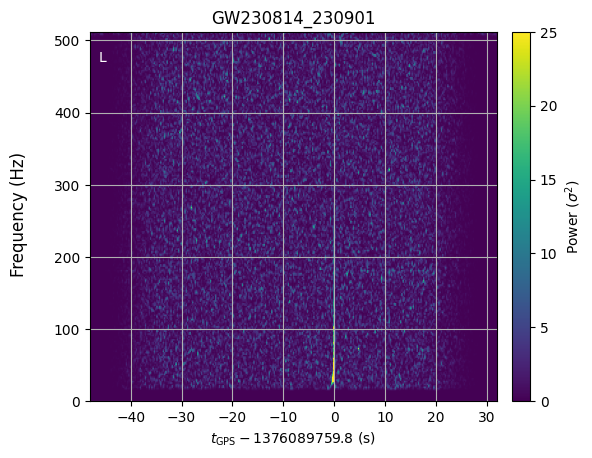

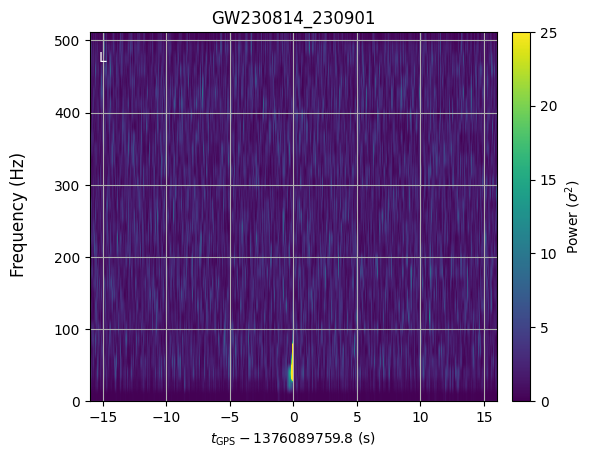

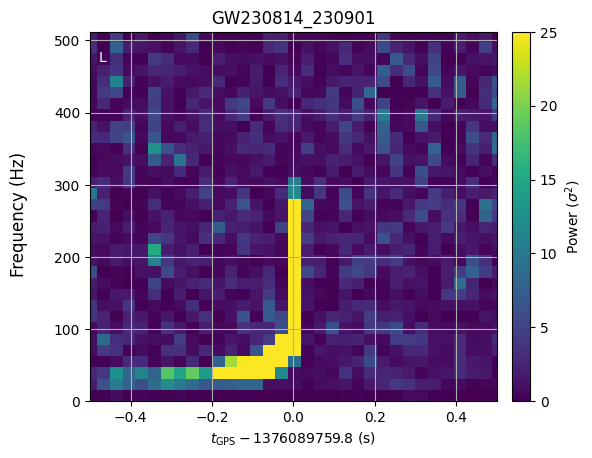

In [8]:
# check out the spectrogram
event_data.specgram(nfft=512)
kwargs = dict(
    fmax = 256,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))
plt.show()

In [9]:
def load_posterior_samples(eventname, event_path):
    # find the "earliest" run with posterior samples
    i = 0
    while i < 10:
        try:
            samples = pd.read_feather(os.path.join(event_path, f'run_{i}', 'samples.feather'))
            print(f"loaded posterior samples for {eventname} run {i}")
            break
        except FileNotFoundError:
            i += 1

    # add derived quantities
    # add_derived_quantities(samples)

    # load the posterior samples from the LIGO PE data release
    pe_data_fn = f"../data/pe_data_release/IGWN-GWTC4p0-1a206db3d_721-{eventname}-combined_PEDataRelease.hdf5"
    data = read(pe_data_fn)
    # get the posterior samples using the IMRPhenomXPHM approximant
    samples_lvk = data.samples_dict["C00:IMRPhenomXPHM-SpinTaylor"]

    return samples, samples_lvk

In [24]:
# where we've saved the posteriors and samples
resdir = '../data/pe_runs_lensing/IntrinsicLVCPrior'
event_path = os.path.join(resdir, eventname)
samples, samples_lvk = load_posterior_samples(eventname, event_path)

loaded posterior samples for GW230814_230901 run 0


In [43]:
plot_params = [
    'mchirp',
    'lnq',
    'iota',
    'phi_ref',
    'psi',
    'd_luminosity',
    'p_lensed'
]

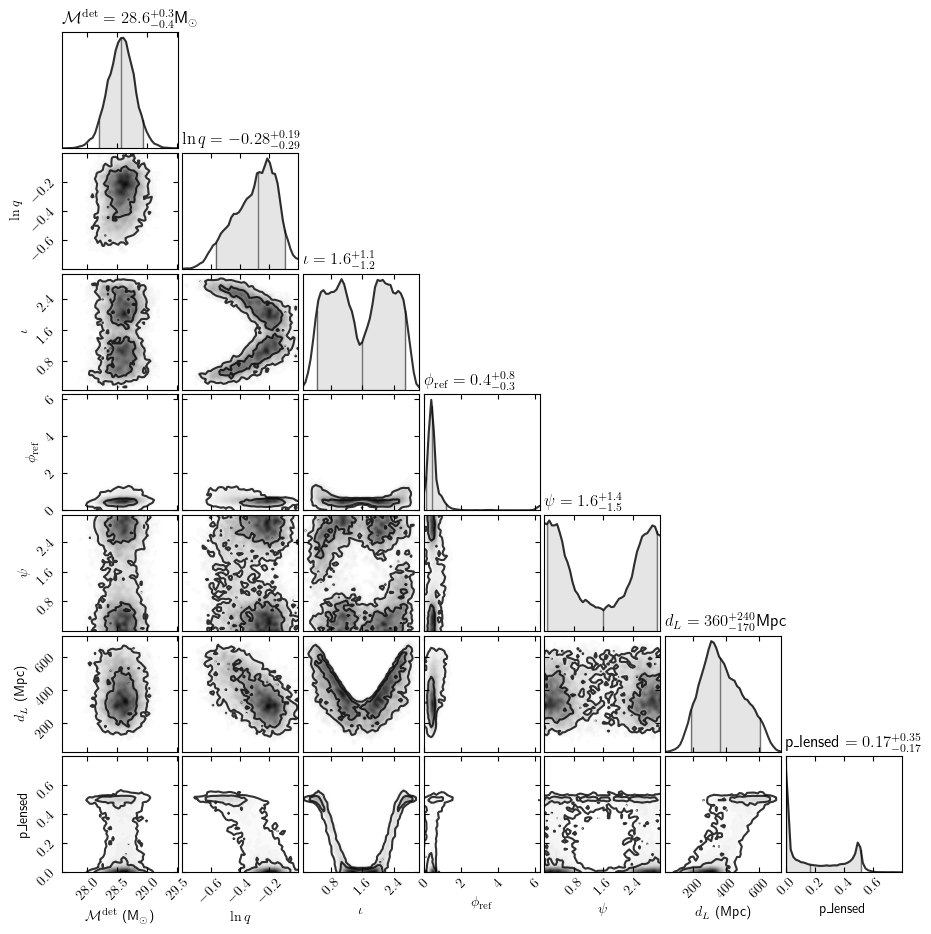

In [44]:
corner_plot = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d='k',
        kwargs_1d=dict(color='k', alpha=0.8), contour_kwargs=dict(alpha=0.8)
)
corner_plot.plot()

<Axes: xlabel='phi_ref', ylabel='p_lensed'>

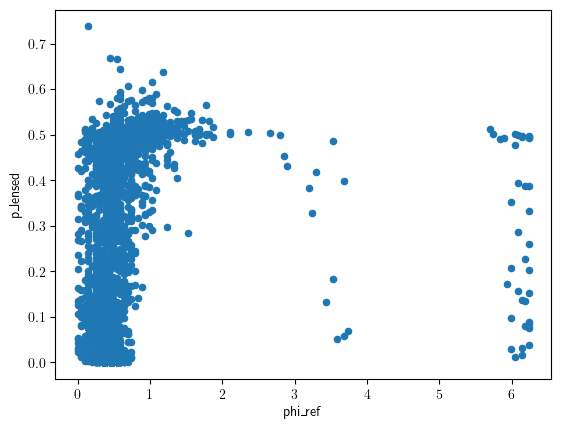

In [45]:
mask = np.random.uniform(size=len(samples)) < (samples['weights'] / samples['weights'].max())
samples[mask].plot('phi_ref', 'p_lensed', 'scatter')

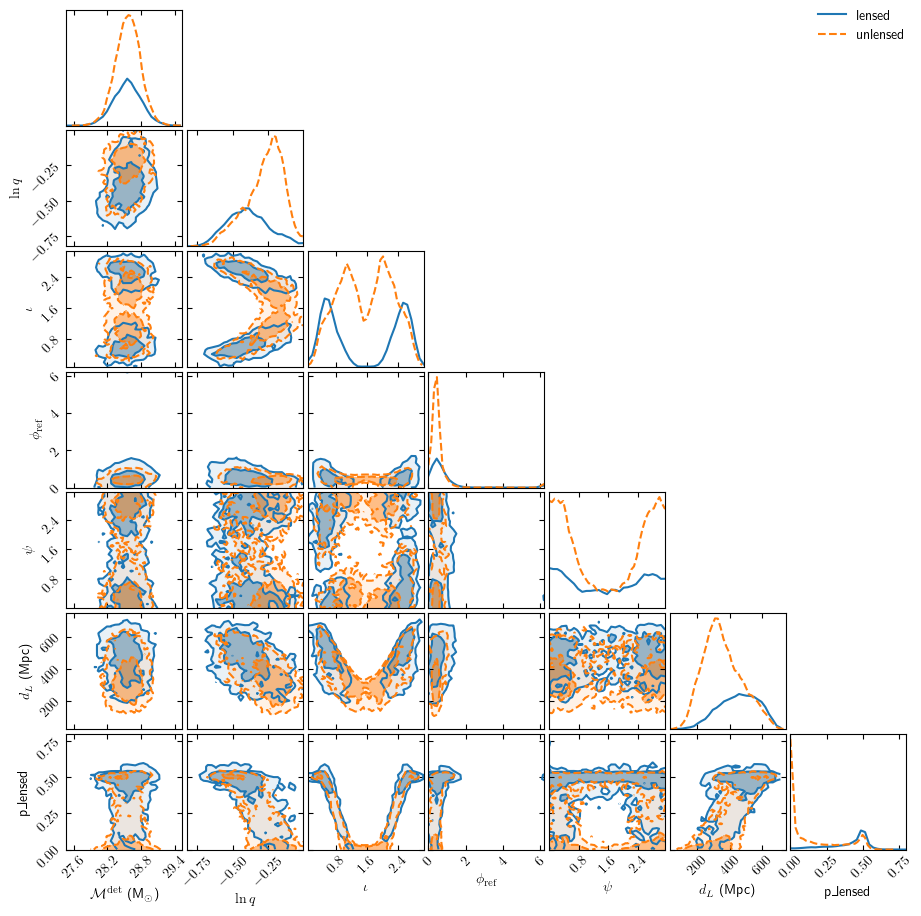

In [46]:
# posterior assuming everything is lensed
lensed = np.random.uniform(size=len(samples)) < samples['p_lensed']

corner_plot = cogwheel.gw_plotting.MultiCornerPlot(
        {'lensed' : samples[lensed], 'unlensed' : samples[~lensed]}, params=plot_params, tail_probability=1e-4, density=False
)
corner_plot.plot()